In [1]:
import pandas as pd
import getpass

from neo4j import GraphDatabase

In [2]:
URI = "neo4j://127.0.0.1:7687"
USERNAME = "neo4j"
DATABASE = "indianarmygraph"

PASSWORD = getpass.getpass("Enter the Neo4j password: ")

driver = GraphDatabase.driver(
    URI,
    auth=(USERNAME, PASSWORD)
)

driver.verify_connectivity()

print("Neo4j connection successful.")

Neo4j connection successful.


In [3]:
result = driver.execute_query(
    """
    MATCH (e:Endpoint)-[:OBSERVED]->(a:Artifact)

    RETURN
        count(DISTINCT e) AS endpoints,
        count(DISTINCT a) AS artifacts,
        count(*) AS relationships
    """,
    database_=DATABASE
)

print(dict(result.records[0]))

{'endpoints': 22, 'artifacts': 49, 'relationships': 49}


In [4]:
def investigate_endpoint(endpoint_id):
    result = driver.execute_query(
        """
        MATCH (e:Endpoint {endpoint_id: $endpoint_id})
              -[r:OBSERVED]->
              (a:Artifact)

        RETURN
            e.endpoint_id AS endpoint,
            a.sha256 AS sha256,
            a.file_names AS file_names,
            r.record_count AS record_count,
            r.first_event AS first_event,
            r.last_event AS last_event

        ORDER BY r.first_event, r.last_event
        """,
        endpoint_id=endpoint_id,
        database_=DATABASE
    )

    if not result.records:
        return None

    return pd.DataFrame(
        [dict(record) for record in result.records]
    )

In [5]:
df = investigate_endpoint("EP4YIFHV")

display(df)

,endpoint,sha256,file_names,record_count,first_event,last_event
0,EP4YIFHV,036965c24ac54284e0bfac480395c91214e7b3c64d0021...,[load-hub-i18n.bundle.js],2,2026-09-11 09:23:33,2026-09-11 09:35:09
1,EP4YIFHV,100d970fc784e9bcb37b707ec4ef69825b165a073659f4...,[shopping_iframe_driver.js],2,2026-09-11 09:23:33,2026-09-11 09:35:09
2,EP4YIFHV,39f5d83d7982cfae057053b0dcffa66fca12bee9769b15...,[tokenized-card.bundle.js],2,2026-09-11 09:23:33,2026-09-11 09:35:09
3,EP4YIFHV,444d4db051edabd5abb29d93dcc5b07e0c662b03e2d785...,[wallet_checkout_autofill_driver.js],2,2026-09-11 09:23:33,2026-09-11 09:35:09
4,EP4YIFHV,4aab5c4ac7a5cf0aab311362514cda20a2f3beb777a553...,[wallet-buynow.bundle.js],2,2026-09-11 09:23:33,2026-09-11 09:35:09
5,EP4YIFHV,528c866fabbe17c30e9790a12ac09b94dd820ba4e46b0f...,[wallet_donation_driver.js],2,2026-09-11 09:23:33,2026-09-11 09:35:09
6,EP4YIFHV,569e425e7f048b1f769c22d65aa91427b69c3d248068af...,[runtime.bundle.js],2,2026-09-11 09:23:33,2026-09-11 09:35:09
7,EP4YIFHV,56bada50510d97878d514009279c3a662d9894a21c344f...,[load-ec-i18n.bundle.js],2,2026-09-11 09:23:33,2026-09-11 09:35:09
8,EP4YIFHV,620389d26167bea08e56a90480f74d3dbd32c3e974f4de...,[bnpl.bundle.js],2,2026-09-11 09:23:33,2026-09-11 09:35:09
9,EP4YIFHV,6c21396c9518fa414ddb4dada2adb09e2d2b2fc5069d89...,[bnpl_driver.js],2,2026-09-11 09:23:33,2026-09-11 09:35:09


In [6]:
def investigate_artifact(sha256):
    result = driver.execute_query(
        """
        MATCH (e:Endpoint)-[r:OBSERVED]->
              (a:Artifact {sha256: $sha256})

        RETURN
            e.endpoint_id AS endpoint,
            a.sha256 AS sha256,
            a.file_names AS file_names,
            r.record_count AS record_count,
            r.first_event AS first_event,
            r.last_event AS last_event

        ORDER BY r.first_event
        """,
        sha256=sha256,
        database_=DATABASE
    )

    if not result.records:
        return None

    return pd.DataFrame(
        [dict(record) for record in result.records]
    )

In [7]:
sha256 = df.iloc[0]["sha256"]

artifact_df = investigate_artifact(sha256)

display(artifact_df)

,endpoint,sha256,file_names,record_count,first_event,last_event
0,EP4YIFHV,036965c24ac54284e0bfac480395c91214e7b3c64d0021...,[load-hub-i18n.bundle.js],2,2026-09-11 09:23:33,2026-09-11 09:35:09


In [8]:
def endpoint_report(endpoint_id):
    summary_result = driver.execute_query(
        """
        MATCH (e:Endpoint {endpoint_id: $endpoint_id})
              -[r:OBSERVED]->
              (a:Artifact)

        RETURN
            e.endpoint_id AS endpoint,
            count(DISTINCT a) AS unique_artifacts,
            sum(r.record_count) AS total_observations,
            min(r.first_event) AS first_observation,
            max(r.last_event) AS last_observation
        """,
        endpoint_id=endpoint_id,
        database_=DATABASE
    )

    if not summary_result.records:
        return None

    summary = dict(summary_result.records[0])

    artifacts = investigate_endpoint(endpoint_id)

    return {
        "summary": summary,
        "artifacts": artifacts
    }

In [9]:
report = endpoint_report("EP4YIFHV")

print("ENDPOINT INVESTIGATION REPORT")
print("=" * 40)

for key, value in report["summary"].items():
    print(f"{key}: {value}")

print("\nARTIFACTS")
print("=" * 40)

display(report["artifacts"])

ENDPOINT INVESTIGATION REPORT
endpoint: EP4YIFHV
unique_artifacts: 20
total_observations: 40
first_observation: 2026-09-11 09:23:33
last_observation: 2026-09-11 09:35:09

ARTIFACTS


,endpoint,sha256,file_names,record_count,first_event,last_event
0,EP4YIFHV,036965c24ac54284e0bfac480395c91214e7b3c64d0021...,[load-hub-i18n.bundle.js],2,2026-09-11 09:23:33,2026-09-11 09:35:09
1,EP4YIFHV,100d970fc784e9bcb37b707ec4ef69825b165a073659f4...,[shopping_iframe_driver.js],2,2026-09-11 09:23:33,2026-09-11 09:35:09
2,EP4YIFHV,39f5d83d7982cfae057053b0dcffa66fca12bee9769b15...,[tokenized-card.bundle.js],2,2026-09-11 09:23:33,2026-09-11 09:35:09
3,EP4YIFHV,444d4db051edabd5abb29d93dcc5b07e0c662b03e2d785...,[wallet_checkout_autofill_driver.js],2,2026-09-11 09:23:33,2026-09-11 09:35:09
4,EP4YIFHV,4aab5c4ac7a5cf0aab311362514cda20a2f3beb777a553...,[wallet-buynow.bundle.js],2,2026-09-11 09:23:33,2026-09-11 09:35:09
5,EP4YIFHV,528c866fabbe17c30e9790a12ac09b94dd820ba4e46b0f...,[wallet_donation_driver.js],2,2026-09-11 09:23:33,2026-09-11 09:35:09
6,EP4YIFHV,569e425e7f048b1f769c22d65aa91427b69c3d248068af...,[runtime.bundle.js],2,2026-09-11 09:23:33,2026-09-11 09:35:09
7,EP4YIFHV,56bada50510d97878d514009279c3a662d9894a21c344f...,[load-ec-i18n.bundle.js],2,2026-09-11 09:23:33,2026-09-11 09:35:09
8,EP4YIFHV,620389d26167bea08e56a90480f74d3dbd32c3e974f4de...,[bnpl.bundle.js],2,2026-09-11 09:23:33,2026-09-11 09:35:09
9,EP4YIFHV,6c21396c9518fa414ddb4dada2adb09e2d2b2fc5069d89...,[bnpl_driver.js],2,2026-09-11 09:23:33,2026-09-11 09:35:09


In [10]:
artifact_view = report["artifacts"][
    [
        "sha256",
        "file_names",
        "record_count",
        "first_event",
        "last_event"
    ]
]

display(artifact_view)

,sha256,file_names,record_count,first_event,last_event
0,036965c24ac54284e0bfac480395c91214e7b3c64d0021...,[load-hub-i18n.bundle.js],2,2026-09-11 09:23:33,2026-09-11 09:35:09
1,100d970fc784e9bcb37b707ec4ef69825b165a073659f4...,[shopping_iframe_driver.js],2,2026-09-11 09:23:33,2026-09-11 09:35:09
2,39f5d83d7982cfae057053b0dcffa66fca12bee9769b15...,[tokenized-card.bundle.js],2,2026-09-11 09:23:33,2026-09-11 09:35:09
3,444d4db051edabd5abb29d93dcc5b07e0c662b03e2d785...,[wallet_checkout_autofill_driver.js],2,2026-09-11 09:23:33,2026-09-11 09:35:09
4,4aab5c4ac7a5cf0aab311362514cda20a2f3beb777a553...,[wallet-buynow.bundle.js],2,2026-09-11 09:23:33,2026-09-11 09:35:09
5,528c866fabbe17c30e9790a12ac09b94dd820ba4e46b0f...,[wallet_donation_driver.js],2,2026-09-11 09:23:33,2026-09-11 09:35:09
6,569e425e7f048b1f769c22d65aa91427b69c3d248068af...,[runtime.bundle.js],2,2026-09-11 09:23:33,2026-09-11 09:35:09
7,56bada50510d97878d514009279c3a662d9894a21c344f...,[load-ec-i18n.bundle.js],2,2026-09-11 09:23:33,2026-09-11 09:35:09
8,620389d26167bea08e56a90480f74d3dbd32c3e974f4de...,[bnpl.bundle.js],2,2026-09-11 09:23:33,2026-09-11 09:35:09
9,6c21396c9518fa414ddb4dada2adb09e2d2b2fc5069d89...,[bnpl_driver.js],2,2026-09-11 09:23:33,2026-09-11 09:35:09


In [11]:
result = driver.execute_query(
    """
    MATCH (e:Endpoint)-[:OBSERVED]->(a:Artifact)

    RETURN
        e.endpoint_id AS endpoint,
        count(DISTINCT a) AS artifact_count
    ORDER BY artifact_count DESC
    """,
    database_=DATABASE
)

endpoint_counts_df = pd.DataFrame(
    [dict(record) for record in result.records]
)

display(endpoint_counts_df)

,endpoint,artifact_count
0,EP4YIFHV,20
1,EPMVZYZO,4
2,EPVSWBNA,3
3,EPAJI3E5,2
4,EPJ42VCZ,2
5,EPPGWIOF,2
6,EP7UYCXM,1
7,EPAGTKNF,1
8,EPEEHWSG,1
9,EPGSQVEB,1


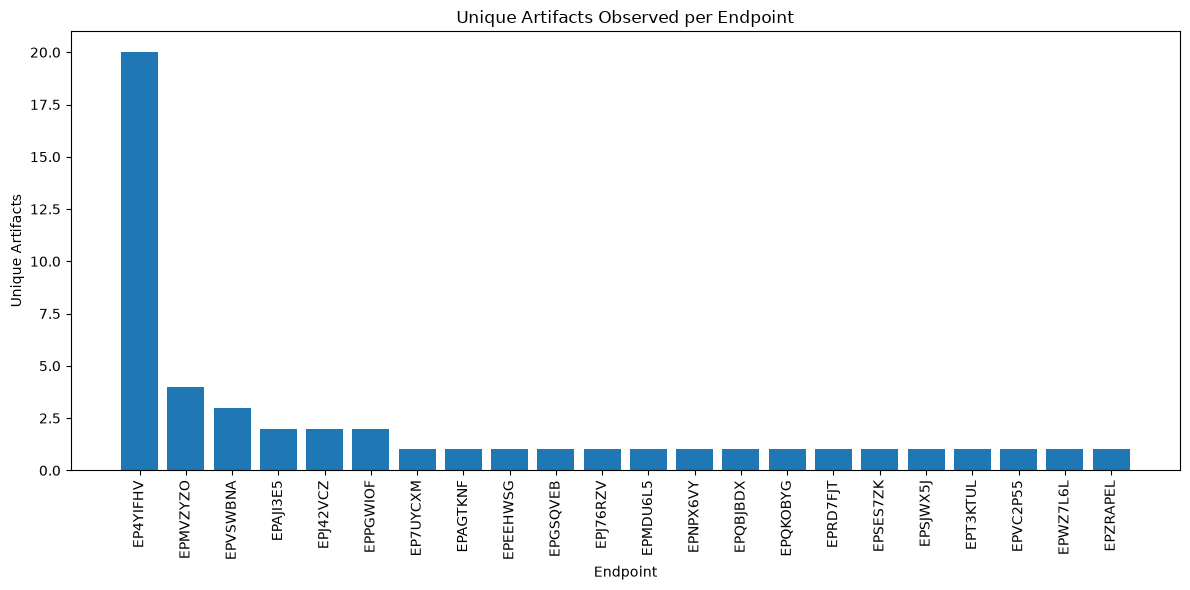

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    endpoint_counts_df["endpoint"],
    endpoint_counts_df["artifact_count"]
)

plt.xlabel("Endpoint")
plt.ylabel("Unique Artifacts")
plt.title("Unique Artifacts Observed per Endpoint")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

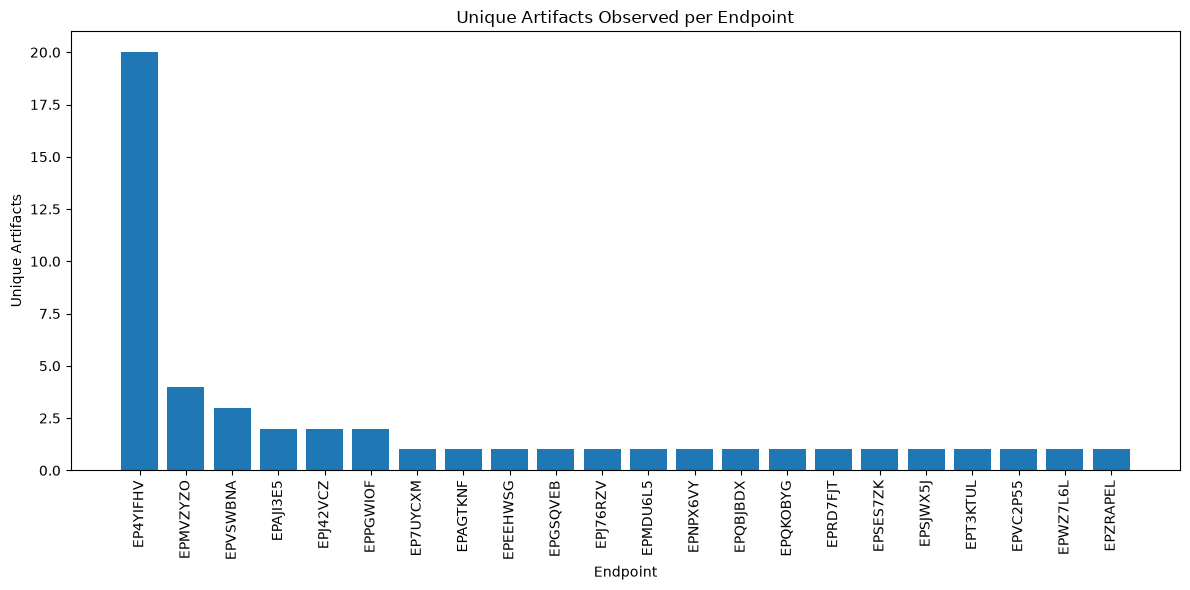

In [13]:
plt.figure(figsize=(12, 6))

plt.bar(
    endpoint_counts_df["endpoint"],
    endpoint_counts_df["artifact_count"]
)

plt.xlabel("Endpoint")
plt.ylabel("Unique Artifacts")
plt.title("Unique Artifacts Observed per Endpoint")

plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig(
    "../data/unique_artifacts_per_endpoint.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Malicious Evidence Investigation

This section separates explicit security detections from heuristic activity
indicators.

`malicious_detected = true` means the source endpoint-security telemetry
explicitly classified the observation as malicious.

It does **not** by itself prove execution, persistence, lateral movement, or
complete endpoint compromise.


In [14]:

# Retrieve endpoint-artifact relationships with explicit malicious evidence.
malicious_result = driver.execute_query(
    """
    MATCH (e:Endpoint)-[r:OBSERVED]->(a:Artifact)
    WHERE r.malicious_detected = true

    RETURN
        e.endpoint_id AS endpoint,
        a.sha256 AS sha256,
        a.file_names AS file_names,
        r.record_count AS record_count,
        r.malicious_detection_count AS detection_count,
        r.malicious_file_names AS malicious_file_names,
        r.first_malicious_detection AS first_detection,
        r.last_malicious_detection AS last_detection,
        r.first_quarantine_time AS first_quarantine,
        r.last_quarantine_time AS last_quarantine

    ORDER BY r.first_malicious_detection
    """,
    database_=DATABASE
)

malicious_evidence = pd.DataFrame(
    [dict(record) for record in malicious_result.records]
)

display(malicious_evidence)


,endpoint,sha256,file_names,record_count,detection_count,malicious_file_names,first_detection,last_detection,first_quarantine,last_quarantine
0,EPZRAPEL,2e4dff1672bbabba74a0a99d54e38e56e036ce84719895...,[53EDA42869D426262B752F088EA605187284ACE8],1,1,[['53EDA42869D426262B752F088EA605187284ACE8']],2026-09-01 04:58:58,2026-09-01 04:58:58,2026-08-31 13:21:00,2026-08-31 13:21:00
1,EPAGTKNF,18866b6f7308f73bc1b63193e50629bfd4fff701d6b9d3...,"[Buy CP PLUS Dashboard Camera, Warranty NONE 1...",2,2,"[['Buy CP PLUS Dashboard Camera, Warranty NONE...",2026-09-03 19:03:33,2026-09-04 18:10:01,2026-09-03 11:25:00,2026-09-03 11:25:00
2,EPJ42VCZ,854b8f7716627df333e8ecfeae5887c02b3195658f7394...,[RAGHAV STNA STNB.pdf],1,1,[['RAGHAV STNA STNB.pdf']],2026-09-07 08:43:44,2026-09-07 08:43:44,2026-09-06 10:32:00,2026-09-06 10:32:00
3,EPJ42VCZ,a2beca1870ae689f4b046a20c3d8e2e48557d782dea534...,[RAGHAV STNC STNA.pdf],1,1,[['RAGHAV STNC STNA.pdf']],2026-09-07 08:43:44,2026-09-07 08:43:44,2026-09-06 10:20:00,2026-09-06 10:20:00
4,EPPGWIOF,64efda7704564dd50c7514e74ef3c5252bc68af8f3b0d9...,[rawtobr3],5,5,[['rawtobr3']],2026-09-07 11:25:38,2026-09-08 08:12:56,2026-09-07 10:58:00,2026-09-07 10:58:00
5,EPPGWIOF,6594cac08d03782ad43d6b293faff904f20032c8eb37a1...,[brprintconflsr3],5,5,[['brprintconflsr3']],2026-09-07 11:25:38,2026-09-08 08:12:56,2026-09-07 10:57:00,2026-09-07 10:57:00
6,EPQKOBYG,f475a7462dd85932ad7f99354751663d1543adb5e37c7c...,[win-lbp623-621-fw-v1301(1).exe],1,1,[['win-lbp623-621-fw-v1301(1).exe']],2026-09-08 08:31:09,2026-09-08 08:31:09,2026-09-07 13:57:00,2026-09-07 13:57:00
7,EPMDU6L5,5dd59e8309b4be90aad58871d82a5b3fb6dcd7ff19a7fb...,[recently-used.xbel],1,1,[['recently-used.xbel']],2026-09-08 11:58:09,2026-09-08 11:58:09,2026-05-13 13:24:00,2026-05-13 13:24:00
8,EPEEHWSG,98d119993c27068f00bdf18a17d6613ae6ce6046b6b662...,[Library Books.xlsx],1,1,[['Library Books.xlsx']],2026-09-10 09:15:06,2026-09-10 09:15:06,2026-09-08 21:19:00,2026-09-08 21:19:00
9,EP4YIFHV,036965c24ac54284e0bfac480395c91214e7b3c64d0021...,[load-hub-i18n.bundle.js],2,2,[['load-hub-i18n.bundle.js']],2026-09-11 09:23:33,2026-09-11 09:35:09,2026-09-10 13:30:00,2026-09-10 13:30:00


In [15]:

# Summarize explicit malicious detections by endpoint.
endpoint_malicious_result = driver.execute_query(
    """
    MATCH (e:Endpoint)-[r:OBSERVED]->(a:Artifact)
    WHERE r.malicious_detected = true

    RETURN
        e.endpoint_id AS endpoint,
        count(DISTINCT a) AS malicious_artifacts,
        sum(r.malicious_detection_count) AS malicious_detections,
        min(r.first_malicious_detection) AS first_malicious_detection,
        max(r.last_malicious_detection) AS last_malicious_detection,
        min(r.first_quarantine_time) AS first_quarantine_time,
        max(r.last_quarantine_time) AS last_quarantine_time

    ORDER BY malicious_artifacts DESC
    """,
    database_=DATABASE
)

endpoint_malicious_summary = pd.DataFrame(
    [dict(record) for record in endpoint_malicious_result.records]
)

display(endpoint_malicious_summary)


,endpoint,malicious_artifacts,malicious_detections,first_malicious_detection,last_malicious_detection,first_quarantine_time,last_quarantine_time
0,EP4YIFHV,20,40,2026-09-11 09:23:33,2026-09-11 09:35:09,2026-09-10 13:30:00,2026-09-10 13:30:00
1,EPMVZYZO,4,4,2026-09-13 17:27:55,2026-09-13 17:27:55,2026-09-12 09:23:00,2026-09-12 16:26:00
2,EPVSWBNA,3,3,2026-09-24 12:10:16,2026-09-24 12:10:16,2026-09-23 13:20:00,2026-09-23 13:20:00
3,EPAJI3E5,2,4,2026-09-17 16:43:44,2026-09-18 08:28:01,2026-09-17 12:44:00,2026-09-17 12:59:00
4,EPJ42VCZ,2,2,2026-09-07 08:43:44,2026-09-07 08:43:44,2026-09-06 10:20:00,2026-09-06 10:32:00
5,EPPGWIOF,2,10,2026-09-07 11:25:38,2026-09-08 08:12:56,2026-09-07 10:57:00,2026-09-07 10:58:00
6,EP7UYCXM,1,1,2026-09-26 15:25:25,2026-09-26 15:25:25,2026-09-26 08:17:00,2026-09-26 08:17:00
7,EPAGTKNF,1,2,2026-09-03 19:03:33,2026-09-04 18:10:01,2026-09-03 11:25:00,2026-09-03 11:25:00
8,EPEEHWSG,1,1,2026-09-10 09:15:06,2026-09-10 09:15:06,2026-09-08 21:19:00,2026-09-08 21:19:00
9,EPGSQVEB,1,1,2026-09-11 10:11:45,2026-09-11 10:11:45,2026-09-10 15:38:00,2026-09-10 15:38:00


In [16]:

# Investigate the endpoint that previously showed the highest artifact
# concentration while keeping malicious evidence explicitly visible.
target_endpoint = "EP4YIFHV"

targeted_result = driver.execute_query(
    """
    MATCH (e:Endpoint {endpoint_id: $endpoint_id})
          -[r:OBSERVED]->
          (a:Artifact)

    RETURN
        e.endpoint_id AS endpoint,
        a.sha256 AS sha256,
        a.file_names AS file_names,
        r.record_count AS record_count,
        r.malicious_detected AS malicious_detected,
        r.malicious_detection_count AS detection_count,
        r.malicious_file_names AS malicious_file_names,
        r.first_event AS first_event,
        r.last_event AS last_event,
        r.first_malicious_detection AS first_malicious_detection,
        r.last_malicious_detection AS last_malicious_detection,
        r.first_quarantine_time AS first_quarantine_time,
        r.last_quarantine_time AS last_quarantine_time

    ORDER BY r.first_event
    """,
    endpoint_id=target_endpoint,
    database_=DATABASE
)

targeted_evidence = pd.DataFrame(
    [dict(record) for record in targeted_result.records]
)

display(targeted_evidence)


,endpoint,sha256,file_names,record_count,malicious_detected,detection_count,malicious_file_names,first_event,last_event,first_malicious_detection,last_malicious_detection,first_quarantine_time,last_quarantine_time
0,EP4YIFHV,036965c24ac54284e0bfac480395c91214e7b3c64d0021...,[load-hub-i18n.bundle.js],2,True,2,[['load-hub-i18n.bundle.js']],2026-09-11 09:23:33,2026-09-11 09:35:09,2026-09-11 09:23:33,2026-09-11 09:35:09,2026-09-10 13:30:00,2026-09-10 13:30:00
1,EP4YIFHV,100d970fc784e9bcb37b707ec4ef69825b165a073659f4...,[shopping_iframe_driver.js],2,True,2,[['shopping_iframe_driver.js']],2026-09-11 09:23:33,2026-09-11 09:35:09,2026-09-11 09:23:33,2026-09-11 09:35:09,2026-09-10 13:30:00,2026-09-10 13:30:00
2,EP4YIFHV,39f5d83d7982cfae057053b0dcffa66fca12bee9769b15...,[tokenized-card.bundle.js],2,True,2,[['tokenized-card.bundle.js']],2026-09-11 09:23:33,2026-09-11 09:35:09,2026-09-11 09:23:33,2026-09-11 09:35:09,2026-09-10 13:30:00,2026-09-10 13:30:00
3,EP4YIFHV,444d4db051edabd5abb29d93dcc5b07e0c662b03e2d785...,[wallet_checkout_autofill_driver.js],2,True,2,[['wallet_checkout_autofill_driver.js']],2026-09-11 09:23:33,2026-09-11 09:35:09,2026-09-11 09:23:33,2026-09-11 09:35:09,2026-09-10 13:30:00,2026-09-10 13:30:00
4,EP4YIFHV,4aab5c4ac7a5cf0aab311362514cda20a2f3beb777a553...,[wallet-buynow.bundle.js],2,True,2,[['wallet-buynow.bundle.js']],2026-09-11 09:23:33,2026-09-11 09:35:09,2026-09-11 09:23:33,2026-09-11 09:35:09,2026-09-10 13:30:00,2026-09-10 13:30:00
5,EP4YIFHV,528c866fabbe17c30e9790a12ac09b94dd820ba4e46b0f...,[wallet_donation_driver.js],2,True,2,[['wallet_donation_driver.js']],2026-09-11 09:23:33,2026-09-11 09:35:09,2026-09-11 09:23:33,2026-09-11 09:35:09,2026-09-10 13:30:00,2026-09-10 13:30:00
6,EP4YIFHV,569e425e7f048b1f769c22d65aa91427b69c3d248068af...,[runtime.bundle.js],2,True,2,[['runtime.bundle.js']],2026-09-11 09:23:33,2026-09-11 09:35:09,2026-09-11 09:23:33,2026-09-11 09:35:09,2026-09-10 13:30:00,2026-09-10 13:30:00
7,EP4YIFHV,56bada50510d97878d514009279c3a662d9894a21c344f...,[load-ec-i18n.bundle.js],2,True,2,[['load-ec-i18n.bundle.js']],2026-09-11 09:23:33,2026-09-11 09:35:09,2026-09-11 09:23:33,2026-09-11 09:35:09,2026-09-10 13:30:00,2026-09-10 13:30:00
8,EP4YIFHV,620389d26167bea08e56a90480f74d3dbd32c3e974f4de...,[bnpl.bundle.js],2,True,2,[['bnpl.bundle.js']],2026-09-11 09:23:33,2026-09-11 09:35:09,2026-09-11 09:23:33,2026-09-11 09:35:09,2026-09-10 13:30:00,2026-09-10 13:30:00
9,EP4YIFHV,6c21396c9518fa414ddb4dada2adb09e2d2b2fc5069d89...,[bnpl_driver.js],2,True,2,[['bnpl_driver.js']],2026-09-11 09:23:33,2026-09-11 09:35:09,2026-09-11 09:23:33,2026-09-11 09:35:09,2026-09-10 13:30:00,2026-09-10 13:30:00
